# Character-Level Seq2Seq — Word Reverser (Practice Notebook)

Train a GRU encoder-decoder (`nn.GRU`) with PyTorch to reverse English words character by character, using a simple sequence-to-sequence architecture without attention.

## Setup

In [34]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
import re

import torch
from torch import nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from wordfreq import top_n_list

from dl_roadmap.engine import Trainer, TrainerConfig
from dl_roadmap.utils import LoggerConfig, seed_everything, setup_logger
from dl_roadmap.visualization import plot_training_history

In [36]:
%matplotlib inline

seed_everything()
setup_logger(LoggerConfig(disable_logging=True))

## Dataset

In [37]:
words = top_n_list("en", 50000)

words = [w.lower() for w in words]
words = [w for w in words if re.fullmatch(r"[a-z]+", w)]
words = [w for w in words if len(w) > 2]  # noqa: PLR2004
words = list(dict.fromkeys(words))

print("Word count:", len(words))
print("Sample words:", words[:10])

Word count: 47361
Sample words: ['the', 'and', 'for', 'that', 'you', 'with', 'this', 'was', 'are', 'have']


In [38]:
special_tokens = ["<PAD>", "<BOS>", "<EOS>", "<UNK>"]
alphabet = list("abcdefghijklmnopqrstuvwxyz")

tokens = special_tokens + alphabet

itos = {i: ch for i, ch in enumerate(tokens)}
stoi = {ch: i for i, ch in enumerate(tokens)}

In [39]:
class WordCharDataset(Dataset):
    """Character-level next-token dataset built from a list of words.

    Each word is turned into an input sequence prefixed with ``<BOS>`` and a
    target sequence suffixed with ``<EOS>``, both encoded as character ids.
    """

    def __init__(self, words: list[str], stoi: dict[str, int]) -> None:
        """Initializes the dataset.

        Args:
            words: Words to build sequences from.
            stoi: Mapping from character/token to its id.
        """
        super().__init__()

        self.words = words
        self.stoi = stoi

        self._unk_id = stoi.get("<UNK>", -1)

    def __len__(self) -> int:
        """Returns the number of words in the dataset."""
        return len(self.words)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        """Returns the input/target character id sequences for a word.

        Args:
            idx: Index of the word in the dataset.

        Returns:
            A tuple of the input sequence (``<BOS>`` + word) and the target
            sequence (word + ``<EOS>``), both as long tensors.
        """
        word = self.words[idx]

        x_chars = ["<BOS>", *list(word), "<EOS>"]
        y_chars = ["<BOS>", *list(word)[::-1], "<EOS>"]

        x = torch.tensor(
            [self.stoi.get(ch, self._unk_id) for ch in x_chars],
            dtype=torch.long,
        )
        y = torch.tensor(
            [self.stoi.get(ch, self._unk_id) for ch in y_chars],
            dtype=torch.long,
        )

        return x, y

In [40]:
pad_id = stoi["<PAD>"]


def collate_fn(
    batch: list[tuple[torch.Tensor, torch.Tensor]],
) -> tuple[torch.Tensor, torch.Tensor]:
    """Pads a batch of input/target sequences to the same length.

    Args:
        batch: A list of (input, target) tensor pairs of variable length.

    Returns:
        A tuple of batched input and target tensors, both padded with
        ``pad_id`` and shaped ``batch_size x max_seq_len``.
    """
    xs, ys = zip(*batch)

    xs = pad_sequence(xs, batch_first=True, padding_value=pad_id)
    ys = pad_sequence(ys, batch_first=True, padding_value=pad_id)

    return xs, ys

In [41]:
n = len(words)

train_words = words[: int(0.8 * n)]
val_words = words[int(0.8 * n) :]

train_dataset = WordCharDataset(train_words, stoi)
val_dataset = WordCharDataset(val_words, stoi)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    collate_fn=collate_fn,
)

## Training

In [42]:
class EncoderRNN(nn.Module):
    """GRU-based sequence encoder.

    Embeds character ids and runs them through a GRU, producing the
    per-step hidden states and the final hidden state used to initialize
    the decoder.
    """

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 64,
        hidden_size: int = 128,
        num_layers: int = 1,
        dropout: float = 0.2,
        pad_id: int = 0,
    ) -> None:
        """Initializes the model.

        Args:
            vocab_size: Number of distinct tokens in the vocabulary.
            embedding_dim: Size of the character embedding vectors.
            hidden_size: Size of the RNN hidden state.
            num_layers: Number of stacked RNN layers.
            dropout: Dropout probability applied to the embedded input.
            pad_id: Token id used for padding, ignored by the embedding.
        """
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_id,
        )

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Encodes a batch of input sequences.

        Args:
            x: Input token ids of shape ``batch_size x seq_len``.

        Returns:
            A tuple of the per-step hidden states, shaped
            ``batch_size x seq_len x hidden_size``, and the final hidden
            state, shaped ``num_layers x batch_size x hidden_size``.
        """
        embedding = self.dropout(self.embedding(x))
        output, hidden = self.gru(embedding)
        return output, hidden

In [43]:
class DecoderRNN(nn.Module):
    """GRU-based autoregressive decoder.

    Starting from ``<BOS>``, decodes one character at a time for up to
    ``MAX_LENGTH`` steps. During training, if a target is given, each step
    is fed the ground-truth previous character (teacher forcing) for as
    long as the target sequence lasts; otherwise it greedily feeds back its
    own most likely output.
    """

    MAX_LENGTH = 64

    def __init__(
        self,
        hidden_size: int = 128,
        num_layers: int = 1,
        output_size: int = 64,
        bos_id: int = 1,
    ) -> None:
        """Initializes the model.

        Args:
            hidden_size: Size of the RNN hidden state.
            num_layers: Number of stacked RNN layers.
            output_size: Number of distinct tokens in the vocabulary.
            bos_id: Token id used to seed the first decoding step.
        """
        super().__init__()

        self.bos_id = bos_id

        self.embedding = nn.Embedding(output_size, hidden_size)

        self.gru = nn.GRU(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        self.relu = nn.ReLU()

        self.log_softmax = nn.LogSoftmax(dim=-1)

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(
        self,
        encoder_outputs: torch.Tensor,
        encoder_hidden: torch.Tensor,
        target: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Decodes an output sequence from the encoder state.

        Args:
            encoder_outputs: Encoder per-step hidden states, used only to
                infer the batch size and device.
            encoder_hidden: Encoder final hidden state, used to initialize
                the decoder's hidden state.
            target: Ground-truth token ids of shape ``batch_size x seq_len``,
                used for teacher forcing while ``seq_len < MAX_LENGTH``. If
                None, decoding is free-running (greedy) for every step.

        Returns:
            A tuple of the log-probabilities over the vocabulary for each
            decoded step, shaped ``batch_size x MAX_LENGTH x output_size``,
            and the decoder's final hidden state.
        """
        device = encoder_outputs.device
        target_length = target.size(1) if target is not None else 0

        batch_size = encoder_outputs.size(0)
        dec_input = torch.full(
            (batch_size, 1), self.bos_id, dtype=torch.long, device=device
        )
        hidden = encoder_hidden
        outputs = []

        for index in range(self.MAX_LENGTH):
            output, hidden = self.forward_step(dec_input, hidden)
            outputs.append(output)

            if index < target_length:
                # Teacher forcing: feed the ground-truth character.
                dec_input = target[:, index].unsqueeze(1)
            else:
                # Greedy decoding: feed the most likely character back in.
                _, topi = output.topk(1)
                dec_input = topi.squeeze(-1).detach()

        outputs = torch.cat(outputs, dim=1)
        outputs = self.log_softmax(outputs)
        return outputs, hidden

    def forward_step(
        self,
        dec_input: torch.Tensor,
        hidden: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Runs a single decoding step.

        Args:
            dec_input: Token ids for the current step, shaped
                ``batch_size x 1``.
            hidden: Decoder hidden state from the previous step.

        Returns:
            A tuple of the output logits for the current step, shaped
            ``batch_size x 1 x output_size``, and the updated hidden state.
        """
        embedding = self.embedding(dec_input)
        dec_input = self.relu(embedding)
        output, hidden = self.gru(dec_input, hidden)
        output = self.fc(output)
        return output, hidden

In [44]:
class ReverserSeq2Seq(nn.Module):
    """Encoder-decoder model that reverses a character sequence."""

    def __init__(self) -> None:
        """Initializes the encoder and decoder."""
        super().__init__()

        self.encoder = EncoderRNN(len(stoi))
        self.decoder = DecoderRNN(output_size=len(stoi), bos_id=stoi["<BOS>"])

    def forward(self, x: torch.Tensor, y: torch.Tensor | None = None) -> torch.Tensor:
        """Encodes ``x`` and decodes its reversal.

        Args:
            x: Input token ids of shape ``batch_size x seq_len``.
            y: Target token ids of shape ``batch_size x seq_len``, used for
                teacher forcing. If None, decoding is free-running: each
                step's predicted character is fed back in as the next input.

        Returns:
            Log-probabilities over the vocabulary for each decoded step,
            shaped ``batch_size x MAX_LENGTH x vocab_size``.
        """
        enc_output, enc_hidden = self.encoder.forward(x)
        dec_output, _dec_hidden = self.decoder.forward(enc_output, enc_hidden, y)

        return dec_output

In [45]:
class TeacherForcedTrainer(Trainer):
    """Trainer that feeds ground-truth targets to the model during training.

    Passes ``targets`` as a second argument to the model's ``forward`` only
    while training, so a seq2seq decoder can use teacher forcing. During
    validation the model is called with ``None`` instead, so ``val_loss``
    reflects free-running (autoregressive) decoding quality.
    """

    def _forward(
        self, inputs: torch.Tensor, targets: torch.Tensor, train: bool
    ) -> torch.Tensor:
        """Calls the model with targets attached only during training.

        Args:
            inputs: Batch inputs, already moved to `self.device`.
            targets: Batch targets, already moved to `self.device`.
            train: Whether this call happens during a training pass.

        Returns:
            Model predictions, passed to `self.loss_fn` alongside targets.
        """
        return self.model(inputs, targets if train else None)

In [46]:
model = ReverserSeq2Seq()

ce = nn.NLLLoss(ignore_index=pad_id)


def loss_fn(preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """Computes NLL loss over flattened sequence predictions.

    Args:
        preds: Log-probabilities of shape ``batch_size x seq_len x vocab_size``.
        targets: Target token ids of shape ``batch_size x seq_len``.

    Returns:
        The scalar NLL loss, ignoring ``pad_id`` targets.
    """
    preds = preds[:, : targets.size(1), :]
    return ce(preds.reshape(-1, preds.size(-1)), targets.reshape(-1))


opt = torch.optim.Adam(model.parameters(), lr=1e-3)

trainer_config = TrainerConfig(
    epochs=45, patience=3, min_delta=1e-2, restore_best_weights=True
)
trainer = TeacherForcedTrainer(model, opt, loss_fn, config=trainer_config)
trainer.fit(train_loader, val_loader)

Epoch 25/45:  56%[===========         ] 7400/13320 :: eta=05:02, status=early stopped, train_loss=0.03366, val_loss=0.6027


## Results

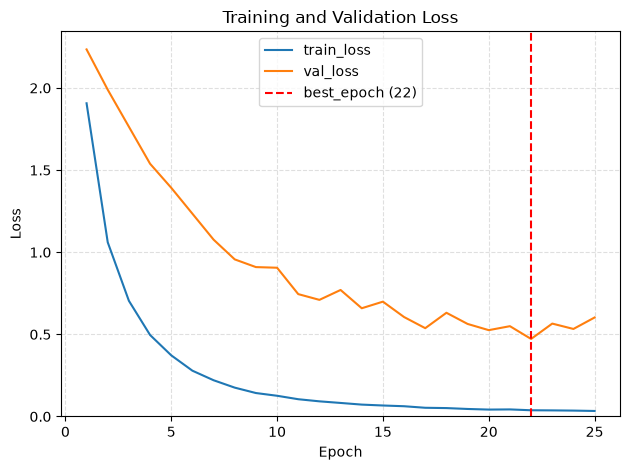

In [51]:
plot_training_history(**trainer.history, best_epoch=trainer.best_epoch)

In [48]:
def reverse_word(
    model: nn.Module,
    word: str,
    stoi: dict[str, int],
    itos: dict[int, str],
    device: str | torch.device = "cuda",
) -> str:
    """Reverses a word using a trained encoder-decoder model.

    Encodes the whole word in a single forward pass and decodes the full
    output sequence produced by the decoder, stopping at ``<EOS>``.

    Args:
        model: A trained encoder-decoder seq2seq model.
        word: The word to reverse.
        stoi: Mapping from character/token to its id.
        itos: Mapping from id to character/token.
        device: Device to run the model on.

    Returns:
        The predicted reversal of ``word``.
    """
    model.eval()

    chars = ["<BOS>", *list(word.lower()), "<EOS>"]
    x = torch.tensor([[stoi[ch] for ch in chars]], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(x)

    ids = logits[0].argmax(dim=-1).tolist()

    result = []
    for i in ids:
        ch = itos[i]
        if ch == "<EOS>":
            break
        if ch not in ("<BOS>", "<PAD>"):
            result.append(ch)

    return "".join(result)

In [49]:
word = "apple"

print(f"input:  {word}")
print(f"output: {reverse_word(model, word, stoi, itos)}")

input:  apple
output: elppa
